<a href="https://colab.research.google.com/github/sasvi123/Neural_Network/blob/main/E22120_lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrheavenly/bach-chorales-dataset")

print("Path to dataset files:", path)

100%|██████████| 114k/114k [00:00<00:00, 61.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mrheavenly/bach-chorales-dataset/versions/1


Using Colab cache for faster access to the 'bach-chorales-dataset' dataset.
Kaggle dataset downloaded to: /kaggle/input/bach-chorales-dataset
Defined extraction path: /content/bach-chorales-dataset
Found .tgz archive: /kaggle/input/bach-chorales-dataset/jsb_chorales.tgz. Extracting to /content/bach-chorales-dataset...
Extraction complete.
No specific data subdirectory found in /content/bach-chorales-dataset. Using base path: /content/bach-chorales-dataset
Searching for data files in: /content/bach-chorales-dataset
Found 382 potential data files (CSV/TXT). Example: /content/bach-chorales-dataset/jsb_chorales/test/chorale_310.csv


/tmp/ipykernel_4053/2981256389.py:217: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extraction_path)


Loaded 382 chorales from /content/bach-chorales-dataset

--- Training Simple RNN ---
Epoch [1/15] | Train Loss: 805.3750 | Val Loss: 20.6910
Epoch [2/15] | Train Loss: 14.6638 | Val Loss: 9.5401
Epoch [3/15] | Train Loss: 10.7294 | Val Loss: 8.7554
Epoch [4/15] | Train Loss: 9.5873 | Val Loss: 7.1055
Epoch [5/15] | Train Loss: 7.7345 | Val Loss: 5.4214
Epoch [6/15] | Train Loss: 6.5036 | Val Loss: 4.8356
Epoch [7/15] | Train Loss: 6.0348 | Val Loss: 4.4491
Epoch [8/15] | Train Loss: 5.8960 | Val Loss: 4.3700
Epoch [9/15] | Train Loss: 5.8455 | Val Loss: 4.2191
Epoch [10/15] | Train Loss: 5.5412 | Val Loss: 4.0909
Epoch [11/15] | Train Loss: 5.4032 | Val Loss: 4.0044
Epoch [12/15] | Train Loss: 5.2942 | Val Loss: 4.6141
Epoch [13/15] | Train Loss: 5.2537 | Val Loss: 3.8443
Epoch [14/15] | Train Loss: 5.2090 | Val Loss: 3.9053
Epoch [15/15] | Train Loss: 5.1682 | Val Loss: 3.8394
Simple RNN Final Test Loss (MSE): 10.0473

--- Training LSTM ---
Epoch [1/15] | Train Loss: 842.8379 | Val Lo

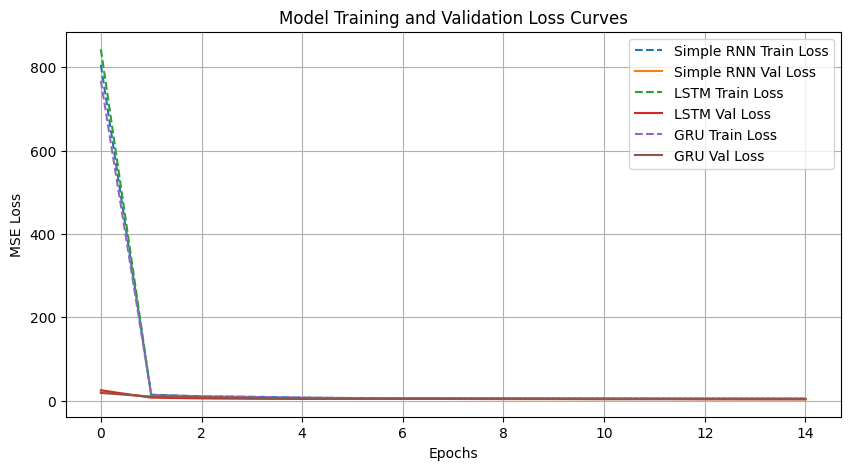


--- First 20 Generated Time Steps ---
    Voice 1  Voice 2  Voice 3  Voice 4
0        74       67       62       49
1        74       67       62       49
2        73       67       62       50
3        73       67       62       50
4        73       67       62       50
5        73       67       62       50
6        73       67       62       50
7        73       67       62       50
8        73       67       62       50
9        73       67       62       50
10       73       67       62       50
11       73       67       62       50
12       73       67       62       50
13       73       67       62       50
14       73       67       62       50
15       73       67       62       50
16       73       67       62       50
17       73       67       62       50
18       73       67       62       50
19       73       67       62       50


In [10]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import kagglehub # Import kagglehub here
import tarfile # Import tarfile for extracting .tgz files

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. Dataset Loading & Preprocessing
def load_bach_chorales(dataset_dir):
    """
    Loads chorales from CSV/TXT files in the dataset directory.
    Each file or dataset entry is structured as sequences of time steps
    where each step has 4 note values.
    """
    chorales = []

    print(f"Searching for data files in: {dataset_dir}")

    # Find all CSV and TXT files recursively
    all_data_files = []
    all_data_files.extend(glob.glob(os.path.join(dataset_dir, "**", "*.csv"), recursive=True))
    all_data_files.extend(glob.glob(os.path.join(dataset_dir, "**", "*.txt"), recursive=True))

    if all_data_files:
        print(f"Found {len(all_data_files)} potential data files (CSV/TXT). Example: {all_data_files[0]}")
    else:
        print("No CSV or TXT files found within the dataset directory structure.")
        # Added debug information to see what's in the directory
        if os.path.exists(dataset_dir):
            print(f"Directory contents of {dataset_dir}: {os.listdir(dataset_dir)}")
        else:
            print(f"Path does not exist: {dataset_dir}")


    for file_path in all_data_files:
        try:
            # Determine file type and read accordingly
            if file_path.endswith('.csv'):
                df = pd.read_csv(file_path)
            elif file_path.endswith('.txt'):
                # Assuming space-delimited for TXT, no header
                df = pd.read_csv(file_path, header=None, delim_whitespace=True)
            else:
                continue # Skip unknown file types, though glob should prevent this

            # Select numeric columns corresponding to the 4 note indices
            note_cols = [col for col in df.columns if 'note' in str(col).lower() or 'pitch' in str(col).lower() or 'ch' in str(col).lower()]

            if len(note_cols) >= 4:
                notes = df[note_cols[:4]].values
            else:
                # Fallback if unlabelled numeric columns. Ensure it has at least 4 numeric columns.
                numeric_cols = df.select_dtypes(include=[np.number])
                if numeric_cols.shape[1] >= 4:
                    notes = numeric_cols.iloc[:, :4].values
                else:
                    print(f"Skipping {file_path}: Not enough numeric columns ({numeric_cols.shape[1]}) found for 4 voices. Columns: {list(df.columns)}")
                    continue

            if len(notes) >= 21:  # Must be longer than input_len + 1 target
                chorales.append(notes)
            else:
                print(f"Skipping {file_path}: Sequence too short ({len(notes)} time steps, needs at least 21). Columns: {list(df.columns)}.")
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    print(f"Loaded {len(chorales)} chorales from {dataset_dir}")
    return chorales

class MusicSequenceDataset(Dataset):
  def __init__(self, sequences, seq_length=20):
      self.samples = []
      # Create input-target pairs using a sliding window
      for chorale in sequences:
          if len(chorale) > seq_length:
              for i in range(len(chorale) - seq_length):
                  inp = chorale[i : i + seq_length]
                  target = chorale[i + seq_length]
                  self.samples.append((inp, target))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
      inp, target = self.samples[idx]
      return torch.tensor(inp, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

# 2. Recurrent Model Architectures
class SimpleRNNModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=1, output_size=4):
        super(SimpleRNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=1, output_size=4):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=1, output_size=4):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


# 3. Training & Evaluation
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * x_batch.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item() * x_batch.size(0)

        val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

def evaluate_model(model, test_loader):
    criterion = nn.MSELoss()
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item() * x_batch.size(0)

    return running_test_loss / len(test_loader.dataset)

def generate_sequence(model, seed_sequence, num_steps=100):
    model.eval()
    current_seq = np.array(seed_sequence, dtype=np.float32)
    generated = []

    with torch.no_grad():
        for _ in range(num_steps):
            inp = torch.tensor(current_seq[-20:], dtype=torch.float32).unsqueeze(0)
            pred = model(inp).squeeze(0).numpy()
            pred_rounded = np.round(pred).astype(int)
            generated.append(pred_rounded)
            current_seq = np.vstack([current_seq, pred_rounded])

    return np.array(generated)


# 4. Pipeline Execution
if __name__ == "__main__":
    # Dynamically set DATASET_PATH using kagglehub to ensure it's correct and exists
    initial_kaggle_path = kagglehub.dataset_download("mrheavenly/bach-chorales-dataset")
    print(f"Kaggle dataset downloaded to: {initial_kaggle_path}")

    # Define a writable path for extraction in /content/
    extraction_path = os.path.join("/content/", os.path.basename(initial_kaggle_path))
    os.makedirs(extraction_path, exist_ok=True)
    print(f"Defined extraction path: {extraction_path}")

    DATASET_PATH = extraction_path

    # Only proceed if the initial path exists
    if os.path.exists(initial_kaggle_path):
        # Check for and extract .tgz file if present
        tgz_files = glob.glob(os.path.join(initial_kaggle_path, "*.tgz"))
        if tgz_files:
            print(f"Found .tgz archive: {tgz_files[0]}. Extracting to {extraction_path}...")
            with tarfile.open(tgz_files[0], "r:gz") as tar:
                tar.extractall(path=extraction_path)
            print("Extraction complete.")
            # After extraction, re-check directory contents for subdirs or data

        found_subdirs = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]

        # Try to find a subdirectory that looks like the dataset name or a generic 'data' folder
        potential_data_dirs = [s for s in found_subdirs if 'bach-chorales-dataset' in s.lower() or 'data' in s.lower()]

        if potential_data_dirs:
            # Prioritize 'bach-chorales-dataset' if it exists, otherwise take the first one.
            chosen_subdir = None
            for pdd in potential_data_dirs:
                if pdd.lower() == 'bach-chorales-dataset':
                    chosen_subdir = pdd
                    break
            if chosen_subdir is None:
                chosen_subdir = potential_data_dirs[0] # Fallback to first found if no specific match

            DATASET_PATH = os.path.join(DATASET_PATH, chosen_subdir)
            print(f"Adjusted DATASET_PATH to a subdirectory: {DATASET_PATH}")
        else:
            print(f"No specific data subdirectory found in {DATASET_PATH}. Using base path: {DATASET_PATH}")
    else:
        # This block should ideally not be reached if kagglehub.dataset_download worked correctly
        print(f"Error: The path provided by kagglehub.dataset_download does not exist: {initial_kaggle_path}")


    # 1. Load Chorales Data
    chorales = load_bach_chorales(DATASET_PATH)

    # If no chorales are loaded, there's nothing to train. Exit or handle gracefully.
    if not chorales:
        print("No chorales loaded. Exiting pipeline execution.")
    else:
        # 2. Divide datasets by chorale (Ensure steps from same chorale stay together)
        n_total = len(chorales)
        n_train = int(0.7 * n_total)
        n_val = int(0.15 * n_total)

        train_data = chorales[:n_train]
        val_data = chorales[n_train:n_train + n_val]
        test_data = chorales[n_train + n_val:]

        # 3. Create Datasets and DataLoaders
        train_dataset = MusicSequenceDataset(train_data, seq_length=20)
        val_dataset = MusicSequenceDataset(val_data, seq_length=20)
        test_dataset = MusicSequenceDataset(test_data, seq_length=20)

        # Ensure datasets are not empty before creating DataLoaders
        if len(train_dataset) == 0:
            print("Train dataset is empty. Cannot proceed with training.")
            exit()
        if len(val_dataset) == 0:
            print("Validation dataset is empty. Cannot proceed with training.")
            exit()
        if len(test_dataset) == 0:
            print("Test dataset is empty. Cannot proceed with evaluation or generation.")
            exit()

        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

        # 4. Train Models
        models = {
            'Simple RNN': SimpleRNNModel(),
            'LSTM': LSTMModel(),
            'GRU': GRUModel()
        }

        results = {}

        for name, model in models.items():
            print(f"\n--- Training {name} ---")
            t_loss, v_loss = train_model(model, train_loader, val_loader, epochs=15)
            test_loss = evaluate_model(model, test_loader)
            results[name] = {'train': t_loss, 'val': v_loss, 'test': test_loss, 'model': model}
            print(f"{name} Final Test Loss (MSE): {test_loss:.4f}")

        # 5. Plot curves
        plt.figure(figsize=(10, 5))
        for name in models.keys():
            plt.plot(results[name]['train'], label=f"{name} Train Loss", linestyle='--')
            plt.plot(results[name]['val'], label=f"{name} Val Loss")
        plt.title("Model Training and Validation Loss Curves")
        plt.xlabel("Epochs")
        plt.ylabel("MSE Loss")
        plt.legend()
        plt.grid(True)
        plt.savefig("loss_curves.png")
        plt.show()

        # 6. Sequence Generation using GRU Model
        # Check if test_data is empty before trying to access elements
        if test_data:
            seed_chorale = test_data[0][:20]
            gen_notes = generate_sequence(results['GRU']['model'], seed_chorale, num_steps=100)

            print("\n--- First 20 Generated Time Steps ---")
            gen_df = pd.DataFrame(gen_notes[:20], columns=["Voice 1", "Voice 2", "Voice 3", "Voice 4"])
            print(gen_df)
        else:
            print("Cannot generate sequence as test_data is empty.")